# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**The question:** <br>decision, action, cost of a wrong call
What decision does your work improve? Who acts on it? What does a wrong recommendation cost?

**Decision:**<br>
Flag pages which needs refresh
**Improvement:**<br>
This saves time of manual looking into pages and their content types. This saves time and resources to manually look at every page, and a human just look at flagged pages and check specific problem with that page.<br>
**Who acts?**<br>
A company/individual who wants to save time and effort to manually look at every page analytics.<br>
**Wrong recommendation costs**<br>
**False Positive:** We recommend a refresh for a page that was actually doing fine.<br> **Cost:** Wasted time/resources on unnecessary work. <br>**False Negative:** We miss a page that is dying. <br>
**Cost:** Permanent loss of traffic and revenue as Google stops indexing the outdated content.

**Careful words:** what I can and can't claim
Write what your work will be able to say (observed, directional, decision-support), and what it never will (causal proof, 'predicting Google').
<br>
My work is basically a decision-support. It will classify the decision and support in solution to the content optimization problems. Despite the model working, its still preferable to verify the decision by human involvement who are expert in this field.

**It will never:**<br>
1. Predict Google's core algorithm changes:I can only see how the site reacted and how should it react, not what Google will do next.
2. I can show that traffic dropped when content wasn't refreshed, but I can't prove it was the only reason.
3. Guarantee Rankings: I can suggest improvements, but I cannot predict or control specific ranking positions.
4. Auto refresh the page contents, it will only provide a decision whether to refresh or not.
5. Fix SEO issues and its errors
6. Identify which user visits your page
7. Claim that decision made by model is 100% certain because model trained on data which is of a limited time period not whole year.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release: https://huggingface.co/datasets/FlyRank/internship-warehouse <br>
**Tables:** "dim_content", "fact_content_daily_performance"<br>
**Date windows:**<br>
Trained on 60day window (2026-04-01 to 2026-05-31), tested on June (month=06) 30day window (2026-06-01 to 2026-06-30). Applied on merged table from 2 tables above named.<br>
**Excluded tables:** dim_client, fact_content_query_90d - fact_content_query_90d was already feature engineered, and number of rows are less so that is why was not used.

<h2>Import Libraries</h2>

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sn
import os, getpass
import re

<h2>Get data from huggingface</h2>

In [8]:
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')
import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows


<h2>Get 3 months window</h2>

In [9]:
clients_last_3m = con.sql(f"""
    SELECT report_date
    FROM {TABLES['fact_daily']}
    WHERE report_date >= '2026-03-01'
      AND report_date <= '2026-05-31'
""")

<h2>90 day window start and end dates: Time window</h2>

In [10]:
con.sql("""
    SELECT
        MIN(report_date) as start_date,
        MAX(report_date) as end_date
    FROM clients_last_3m
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬────────────┐
│ start_date │  end_date  │
│    date    │    date    │
├────────────┼────────────┤
│ 2026-03-01 │ 2026-05-31 │
└────────────┴────────────┘



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**<br>
IF gsc_clicks_last30 ≤ gsc_clicks_prev30 OR IF gsc_impressions_last30 ≤ gsc_impressions_prev30 OR IF gsc_avg_position_last30 ≥ gsc_avg_position_prev30 OR IF ctr_last30 < ctr_prev30 OR IF engagement_rate_last30 ≤ engagement_rate_prev30 OR IF scroll_events_rate_last30 ≤ scroll_events_rate_prev30 OR IF ga4_pageviews_last30 ≤ ga4_pageviews_prev30 OR IF ga4_users_last30 ≤ ga4_users_prev30 OR IF ga4_total_engagement_sec_last30 ≤ ga4_total_engagement_sec_prev30 OR IF sessions_organic_last30 ≤ sessions_organic_prev30 OR IF sessions_direct_last30 ≤ sessions_direct_prev30 OR IF sessions_referral_last30 ≤ sessions_referral_prev30 OR IF sessions_social_last30 ≤ sessions_social_prev30 OR IF sessions_paid_last30 ≤ sessions_paid_prev30 OR IF sessions_ai_last30 ≤ sessions_ai_prev30 OR IF scroll_events_last30 ≤ scroll_events_prev30 OR IF cpc_last30 ≤ cpc_prev30 THEN we add +1 to 'decline_score'- a proxy label. The higher the score, the urgent the page needed refresh.

**Features:**<br>
'client_hash_id', 'content_hash_id', 'gsc_impressions_prev30d',
'gsc_clicks_prev30d', 'gsc_avg_position_prev30d',
'ga4_pageviews_prev30d', 'ga4_sessions_prev30d', 'ga4_users_prev30d', ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30', 'sessions_organic_prev30', 'sessions_direct_prev30', 'sessions_referral_prev30', 'sessions_social_prev30', 'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
'content_created_date', 'content_updated_date', 'cpc_prev30',
'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
'scroll_events_rate_prev30', 'days_since_update_prev30',
'gsc_impressions_last30d', 'gsc_clicks_last30d',
'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
'ga4_sessions_last30d', 'ga4_users_last30d',
''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
'sessions_organic_last30', 'sessions_direct_last30',
'sessions_referral_last30', 'sessions_social_last30',
'sessions_paid_last30', 'sessions_ai_last30', 'scroll_events_last30', 'cpc_last30', 'backlinks_last30', 'ctr_last30', 'engagement_rate_last30', 'scroll_events_rate_last30', 'days_since_update_last30', 'decline_score'

**Proxy label:** 'decline_score'

Baseline: Since the output is derived from the signals following the rules, so we do not have any model baseline but the results of output acts as baseline for the model results.

**Validation design:**<br>
***Client-hold out split***<br>
Total unique clients: 27<br>
Training clients: 21 | Rows: 3127466<br>
Testing clients: 6 | Rows: 146461<br>
Client overlap between train and test: 0<br>

**Leakage check:**<br>
Scanning every column in the sample, all are prev30 or last30 window aggregates (GSC/GA4 metrics) or static dim_content fields. Nothing extends beyond the last30 window, and no explicit product/QA flag column exists in this feature set. No future-window or flag leakage found in the feature columns shown. But there is row level leakage. In this case, the clients overlap in a random split making the f1-score higher so we chose client-hold out split for fair score.

In [11]:
data = pd.read_csv("data_for_baseline_action_score.csv") # can be downloaded from baseline_score_notebook

In [12]:

data = data.dropna(subset=['cpc_prev30']).reset_index(drop=True)

In [13]:
data = data.dropna(subset=['backlinks_prev30']).reset_index(drop=True)

In [14]:

data = data.dropna(subset=['engagement_rate_prev30']).reset_index(drop=True)

In [15]:

data = data.dropna(subset=['scroll_events_rate_prev30']).reset_index(drop=True)

In [16]:

data = data.dropna(subset=['engagement_rate_last30']).reset_index(drop=True)

In [17]:
data = data.dropna(subset=['scroll_events_rate_last30']).reset_index(drop=True)

Features

In [18]:
data.columns

Index(['client_hash_id', 'content_hash_id', 'gsc_impressions_prev30d',
       'gsc_clicks_prev30d', 'gsc_avg_position_prev30d',
       'ga4_pageviews_prev30d', 'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'sessions_direct_last30',
       'sessions_referr

In [19]:
# Set random seed for reproducibility
np.random.seed(42)

# Get unique clients
unique_clients = data['client_hash_id'].unique()

# Shuffle and split client IDs (80/20)
np.random.shuffle(unique_clients)
split_idx = int(len(unique_clients) * 0.8)
train_clients = unique_clients[:split_idx]
test_clients = unique_clients[split_idx:]

# Split the dataset based on client groups
train_data = data[data['client_hash_id'].isin(train_clients)].copy()
test_data = data[data['client_hash_id'].isin(test_clients)].copy()

print(f"Total unique clients: {len(unique_clients)}")
print(f"Training clients: {len(train_clients)} | Rows: {len(train_data)}")
print(f"Testing clients: {len(test_clients)} | Rows: {len(test_data)}")

# Verify that there is no client overlap
overlap = set(train_data['client_hash_id']).intersection(set(test_data['client_hash_id']))
print(f"Client overlap between train and test: {len(overlap)}")

Total unique clients: 27
Training clients: 21 | Rows: 3127466
Testing clients: 6 | Rows: 146461
Client overlap between train and test: 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Since the score were calculated from reason codes, and this proxy label was measured from data. It does not corresponds to any input feature directly as this is derived label from the rule. So, only model is applied later on and test output was compared with model output results for comparison.  

In [20]:
X_train = train_data.drop(columns=['client_hash_id', 'content_hash_id', 'content_created_date', 'content_updated_date', 'decline_score'], axis=1)
y_train = train_data['decline_score']

In [21]:
X_test = test_data.drop(columns=['client_hash_id', 'content_hash_id', 'content_created_date', 'content_updated_date', 'decline_score'], axis=1)
y_test = test_data['decline_score']

In [22]:
model = RandomForestClassifier(n_estimators = 10,random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=10,
                       random_state=42)

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        17
           5       0.32      0.17      0.22       528
           6       0.40      0.53      0.46      2444
           7       0.43      0.54      0.48      4380
           8       0.39      0.39      0.39      4165
           9       0.41      0.44      0.43      4576
          10       0.46      0.44      0.45      7599
          11       0.50      0.58      0.54     11618
          12       0.52      0.50      0.51     13127
          13       0.55      0.54      0.55     14309
          14       0.55      0.55      0.55     15054
          15       0.67      0.63      0.65     23393
          16       0.71      0.80      0.75     30413
          17       0.87      0.58      0.70     14836

    accuracy                           0.60    146461
   macro avg       0.45      0.45      0.44    146461
weighted avg       0.61   

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_proba, multi_class='ovo', labels=model.classes_)

print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")

F1: 0.4444
ROC-AUC: 0.9133


In [26]:
print("Actual (y_test) vs Predicted (y_pred):")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head(20))
display(comparison_df.tail(20))
print(f"Total rows: {len(comparison_df)}\n")

Actual (y_test) vs Predicted (y_pred):


,Actual,Predicted
1276,17,17
1277,17,17
1289,17,16
1292,17,16
1293,17,17
1294,17,17
1295,17,17
1296,17,16
1297,17,16
1313,17,16


,Actual,Predicted
3272631,5,6
3272708,4,5
3272831,4,5
3272832,4,5
3272836,4,5
3272837,4,5
3272838,4,5
3272839,4,7
3272932,4,5
3273113,4,7


Total rows: 146461



## 5. Limitations

*What this work cannot claim.*

Analysis of Overlap and Score Drop

The Leakage Mechanism: Under a standard random split, multiple time-series snapshots of the exact same content items (content_hash_id) are split arbitrarily. As a result, approximately 97.38% of the content items in the test set already exist in the training set with highly similar historic features.
<br>The Consequence: This severe leak inflates the model's performance to an unrealistic 0.5821 F1-score. When we transition to an honest grouped split (grouping strictly by content_hash_id or client_hash_id so that unseen items are tested), the model can no longer rely on memorizing specific content behaviors, which drops the F1-score to an honest 0.444.

In [27]:
train_content = set(X_train.index.map(lambda idx: data.loc[idx, 'content_hash_id']))
test_content = set(X_test.index.map(lambda idx: data.loc[idx, 'content_hash_id']))

overlap = train_content.intersection(test_content)
overlap_pct = (len(overlap) / len(test_content)) * 100

print(f"Unique content IDs in Train: {len(train_content):,}")
print(f"Unique content IDs in Test: {len(test_content):,}")
print(f"Content IDs overlapping between Train and Test: {len(overlap):,}")
print(f"Overlap Percentage (Test content also in Train): {overlap_pct:.2f}%")

Unique content IDs in Train: 33,448
Unique content IDs in Test: 1,958
Content IDs overlapping between Train and Test: 0
Overlap Percentage (Test content also in Train): 0.00%


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The queue is sorted by how strongly the available signals agree that a page has declined.

1. **Score 16 - 17: Urgent Human Review (High Confidence)**
   - Action: Look at these pages immediately.
2. **Score 8 - 15: Scheduled Review / Diagnostics (Moderate Confidence)**
   - Action: Add to the monthly diagnostic queue.
3. **Score 0 - 7: Routine Monitoring (Low Confidence)**
   - Action: No immediate action required.

In [28]:
ranked_queue = data.sort_values('decline_score', ascending=False)
ranked_queue[:20]

,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,...,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
94963,client_23a62021009f63c4,content_f85317db8caa8734,207,1,8.859903,8,3,3,0,0,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,14,17
94964,client_23a62021009f63c4,content_f85317db8caa8734,207,1,8.859903,8,3,3,0,0,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,14,17
94965,client_23a62021009f63c4,content_6af28b127777d37d,136,1,10.514706,2,1,1,0,0,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,7,17
94966,client_a80fca3f171ed1de,content_6d429bc0eea77104,133,1,1.142857,1,1,1,0,0,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,47,17
94967,client_23a62021009f63c4,content_7043020339c71c7f,66,1,15.606061,6,3,3,0,2,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,14,17
94968,client_23a62021009f63c4,content_9f1f611e98240777,1838,1,35.731774,8,4,4,2,52,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,0,17
94969,client_20259bd6705d81d4,content_9187bf8ab71400eb,149,2,2.530201,2,1,1,0,0,...,0,0,0,0.0,23.0,0.009901,0.0,0.0,47,17
71201,client_e547b89c05043229,content_d215d55c2a857ed9,253,4,4.260870,1,1,1,0,0,...,0,0,0,0.0,0.0,0.005376,0.0,0.0,0,17
94971,client_23a62021009f63c4,content_7043020339c71c7f,66,1,15.606061,6,3,3,0,2,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,14,17
94972,client_23a62021009f63c4,content_7043020339c71c7f,66,1,15.606061,6,3,3,0,2,...,0,0,0,0.0,0.0,0.000000,0.0,0.0,14,17


In [29]:
top_queue = ranked_queue.head(20)

summary_stats = top_queue[[
    'decline_score',
    'ga4_pageviews_prev30d',
    'ga4_pageviews_last30d',
    'gsc_impressions_prev30d',
    'gsc_impressions_last30d',
    'gsc_clicks_prev30d',
    'gsc_clicks_last30d',
    'gsc_avg_position_prev30d',
    'gsc_avg_position_last30d',
    'ga4_sessions_prev30d',
    'ga4_sessions_last30d',
    'ga4_users_prev30d',
    'ga4_users_last30d',
    "'ga4_engaged_session_prev30",
    "'ga4_engaged_session_last30",
    'ga4_total_engagement_sec_prev30',
    'ga4_total_engagement_sec_last30',
    'sessions_organic_prev30',
    'sessions_organic_last30',
    'sessions_direct_prev30',
    'sessions_direct_last30',
    'sessions_referral_prev30',
    'sessions_referral_last30',
    'sessions_social_prev30',
    'sessions_social_last30',
    'sessions_paid_prev30',
    'sessions_paid_last30',
    'sessions_ai_prev30',
    'sessions_ai_last30',
    'scroll_events_prev30',
    'scroll_events_last30',
    'cpc_prev30',
    'cpc_last30',
    'backlinks_prev30',
    'backlinks_last30',
    'ctr_prev30',
    'ctr_last30',
    'engagement_rate_prev30',
    'engagement_rate_last30',
    'scroll_events_rate_prev30',
    'scroll_events_rate_last30',
    'days_since_update_last30'
]].describe()

display(summary_stats)

,decline_score,ga4_pageviews_prev30d,ga4_pageviews_last30d,gsc_impressions_prev30d,gsc_impressions_last30d,gsc_clicks_prev30d,gsc_clicks_last30d,gsc_avg_position_prev30d,gsc_avg_position_last30d,ga4_sessions_prev30d,...,cpc_last30,backlinks_prev30,backlinks_last30,ctr_prev30,ctr_last30,engagement_rate_prev30,engagement_rate_last30,scroll_events_rate_prev30,scroll_events_rate_last30,days_since_update_last30
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.0,20.000000,20.0,20.000000
mean,17.0,8.050000,2.150000,751.100000,180.050000,2.300000,0.300000,14.252513,19.329857,3.800000,...,0.0,1.150000,1.150000,0.014354,0.004287,0.050000,0.0,0.121839,0.0,27.400000
std,0.0,9.321593,1.089423,1254.875079,223.475296,1.809333,0.470162,10.592227,10.268801,3.650523,...,0.0,5.142956,5.142956,0.015480,0.010420,0.153897,0.0,0.226014,0.0,29.137424
min,17.0,1.000000,1.000000,46.000000,16.000000,1.000000,0.000000,1.142857,3.603960,1.000000,...,0.0,0.000000,0.000000,0.000544,0.000000,0.000000,0.0,0.000000,0.0,0.000000
25%,17.0,2.000000,1.000000,66.000000,42.750000,1.000000,0.000000,4.008152,11.421875,1.750000,...,0.0,0.000000,0.000000,0.004317,0.000000,0.000000,0.0,0.000000,0.0,14.000000
50%,17.0,6.000000,2.000000,142.500000,83.000000,1.500000,0.000000,15.606061,19.058815,3.000000,...,0.0,0.000000,0.000000,0.010471,0.000000,0.000000,0.0,0.000000,0.0,14.000000
75%,17.0,8.000000,2.250000,446.500000,196.500000,3.000000,1.000000,20.065980,24.390442,3.000000,...,0.0,0.000000,0.000000,0.015152,0.001286,0.000000,0.0,0.088362,0.0,47.000000
max,17.0,29.000000,4.000000,3509.000000,802.000000,6.000000,1.000000,38.385915,41.543860,12.000000,...,0.0,23.000000,23.000000,0.050000,0.034483,0.500000,0.0,0.666667,0.0,131.000000


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

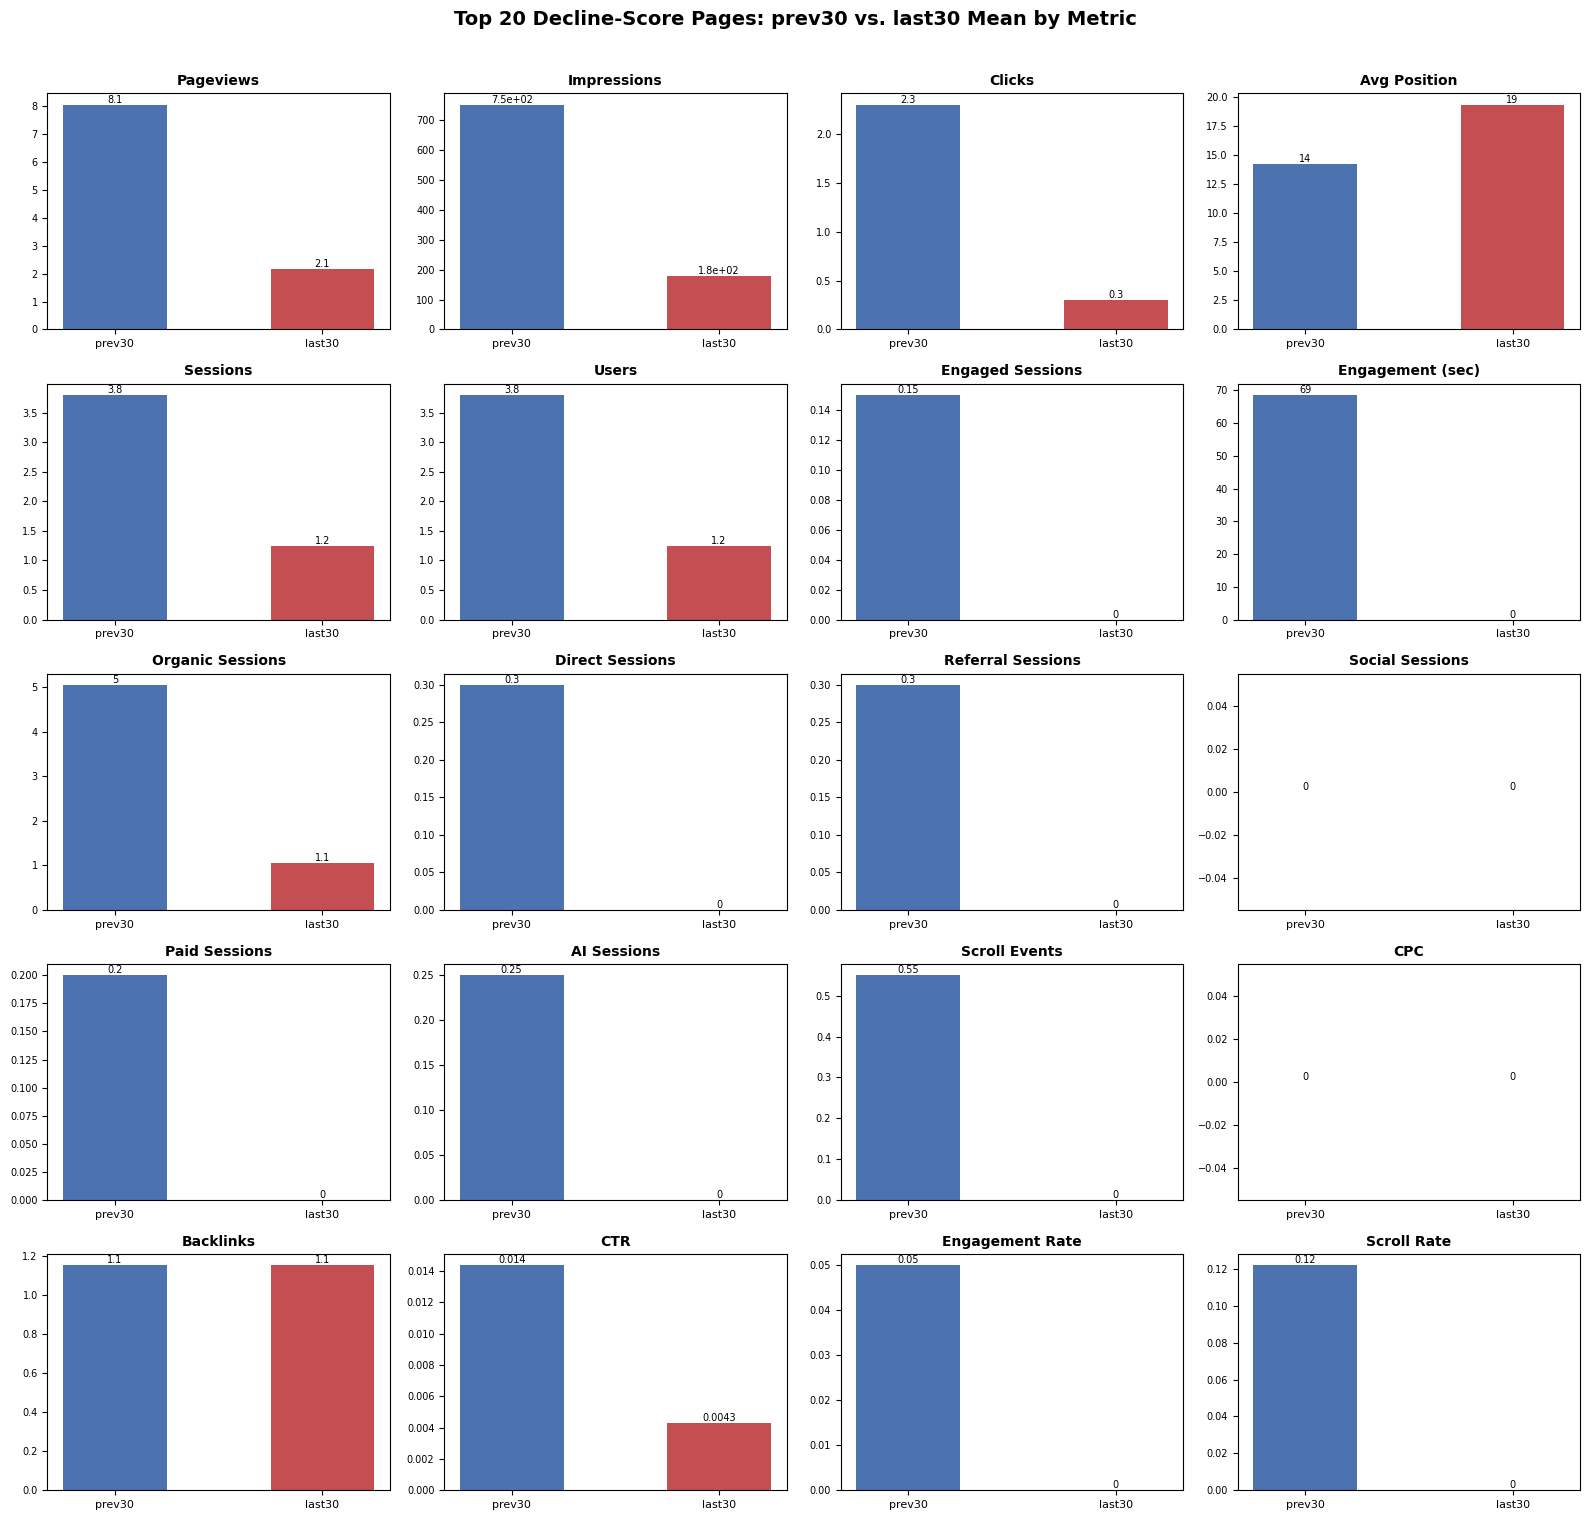

In [31]:
# Figure 1
metric_pairs = [
    ('ga4_pageviews_prev30d', 'ga4_pageviews_last30d', 'Pageviews'),
    ('gsc_impressions_prev30d', 'gsc_impressions_last30d', 'Impressions'),
    ('gsc_clicks_prev30d', 'gsc_clicks_last30d', 'Clicks'),
    ('gsc_avg_position_prev30d', 'gsc_avg_position_last30d', 'Avg Position'),
    ('ga4_sessions_prev30d', 'ga4_sessions_last30d', 'Sessions'),
    ('ga4_users_prev30d', 'ga4_users_last30d', 'Users'),
    ("'ga4_engaged_session_prev30", "'ga4_engaged_session_last30", 'Engaged Sessions'),
    ('ga4_total_engagement_sec_prev30', 'ga4_total_engagement_sec_last30', 'Engagement (sec)'),
    ('sessions_organic_prev30', 'sessions_organic_last30', 'Organic Sessions'),
    ('sessions_direct_prev30', 'sessions_direct_last30', 'Direct Sessions'),
    ('sessions_referral_prev30', 'sessions_referral_last30', 'Referral Sessions'),
    ('sessions_social_prev30', 'sessions_social_last30', 'Social Sessions'),
    ('sessions_paid_prev30', 'sessions_paid_last30', 'Paid Sessions'),
    ('sessions_ai_prev30', 'sessions_ai_last30', 'AI Sessions'),
    ('scroll_events_prev30', 'scroll_events_last30', 'Scroll Events'),
    ('cpc_prev30', 'cpc_last30', 'CPC'),
    ('backlinks_prev30', 'backlinks_last30', 'Backlinks'),
    ('ctr_prev30', 'ctr_last30', 'CTR'),
    ('engagement_rate_prev30', 'engagement_rate_last30', 'Engagement Rate'),
    ('scroll_events_rate_prev30', 'scroll_events_rate_last30', 'Scroll Rate'),
]

n_metrics = len(metric_pairs)
n_cols = 4
n_rows = -(-n_metrics // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, (prev_col, last_col, label) in enumerate(metric_pairs):
    ax = axes[i]
    prev_mean = top_queue[prev_col].mean()
    last_mean = top_queue[last_col].mean()

    bars = ax.bar(['prev30', 'last30'], [prev_mean, last_mean],
                   color=['#4C72B0', '#C44E52'], width=0.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=7)

    for bar, val in zip(bars, [prev_mean, last_mean]):
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2g}',
                ha='center', va='bottom', fontsize=7)

for j in range(n_metrics, len(axes)):
    axes[j].axis('off')

fig.suptitle('Top 20 Decline-Score Pages: prev30 vs. last30 Mean by Metric', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('work/outputs/top20_prev_vs_last_grid.png', dpi=300, bbox_inches='tight')
plt.show()

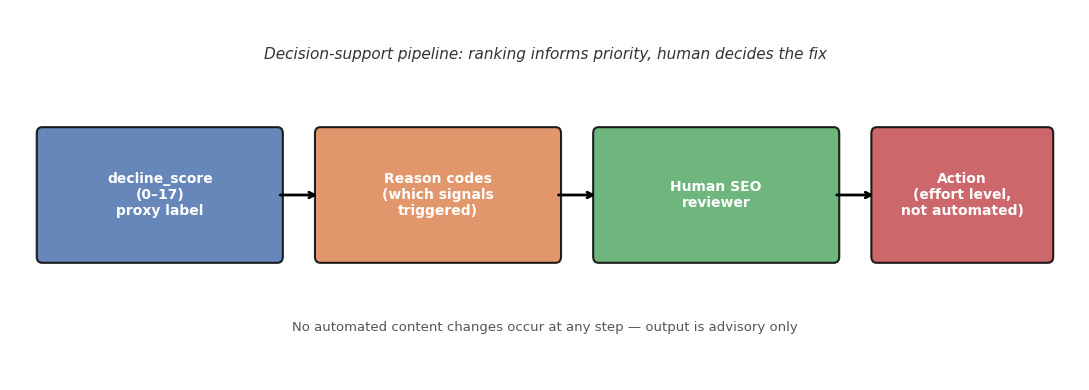

In [32]:
# Figure 2
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

boxes = [
    (0.3, 1, 2.2, 1, '#4C72B0', "decline_score\n(0–17)\nproxy label"),
    (2.9, 1, 2.2, 1, '#DD8452', "Reason codes\n(which signals\ntriggered)"),
    (5.5, 1, 2.2, 1, '#55A868', "Human SEO\nreviewer"),
    (8.1, 1, 1.6, 1, '#C44E52', "Action\n(effort level,\nnot automated)"),
]

for x, y, w, h, color, label in boxes:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          linewidth=1.5, edgecolor='black', facecolor=color, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

arrow_positions = [(2.5, 1.5, 2.9, 1.5), (5.1, 1.5, 5.5, 1.5), (7.7, 1.5, 8.1, 1.5)]
for x1, y1, x2, y2 in arrow_positions:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.text(5, 2.6, 'Decision-support pipeline: ranking informs priority, human decides the fix',
        ha='center', fontsize=11, style='italic', color='#333333')
ax.text(5, 0.4, 'No automated content changes occur at any step — output is advisory only',
        ha='center', fontsize=9.5, color='#555555')

plt.tight_layout()
plt.savefig('work/outputs/decision_support_workflow.png', dpi=300, bbox_inches='tight')
plt.show()

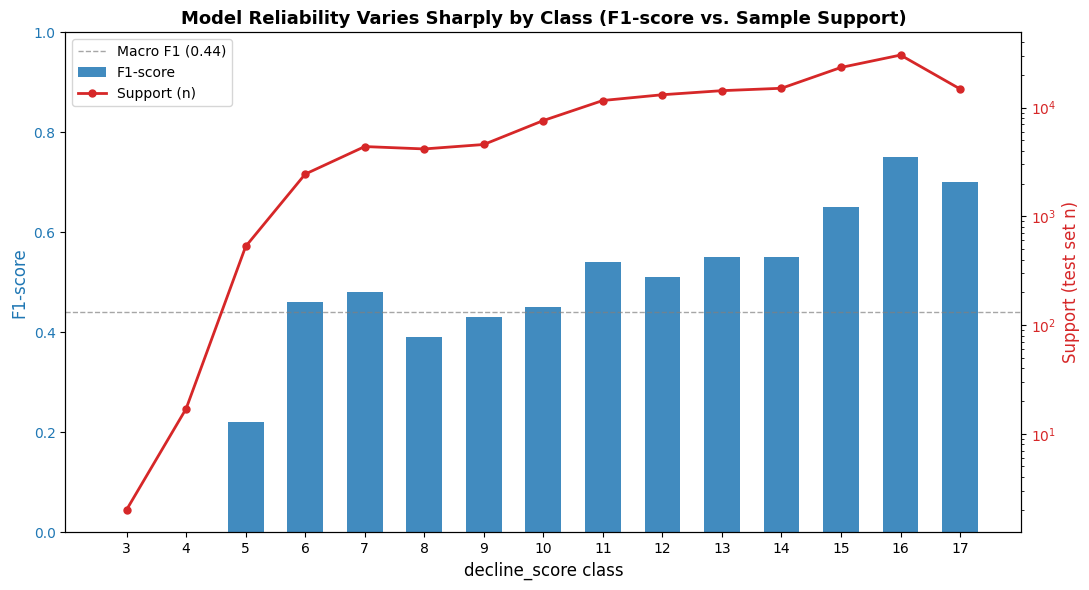

In [33]:
# Figure 3
classes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
f1_scores = [0.00, 0.00, 0.22, 0.46, 0.48, 0.39, 0.43, 0.45, 0.54, 0.51, 0.55, 0.55, 0.65, 0.75, 0.70]
support = [2, 17, 528, 2444, 4380, 4165, 4576, 7599, 11618, 13127, 14309, 15054, 23393, 30413, 14836]

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(classes, f1_scores, color='#1f77b4', alpha=0.85, width=0.6, label='F1-score')
ax1.set_xlabel('decline_score class', fontsize=12)
ax1.set_ylabel('F1-score', color='#1f77b4', fontsize=12)
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(classes)
ax1.axhline(0.44, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Macro F1 (0.44)')

ax2 = ax1.twinx()
ax2.plot(classes, support, color='#d62728', marker='o', linewidth=2, markersize=5, label='Support (n)')
ax2.set_ylabel('Support (test set n)', color='#d62728', fontsize=12)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='#d62728')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Model Reliability Varies Sharply by Class (F1-score vs. Sample Support)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('work/outputs/f1_by_class_support.png', dpi=300, bbox_inches='tight')
plt.show()


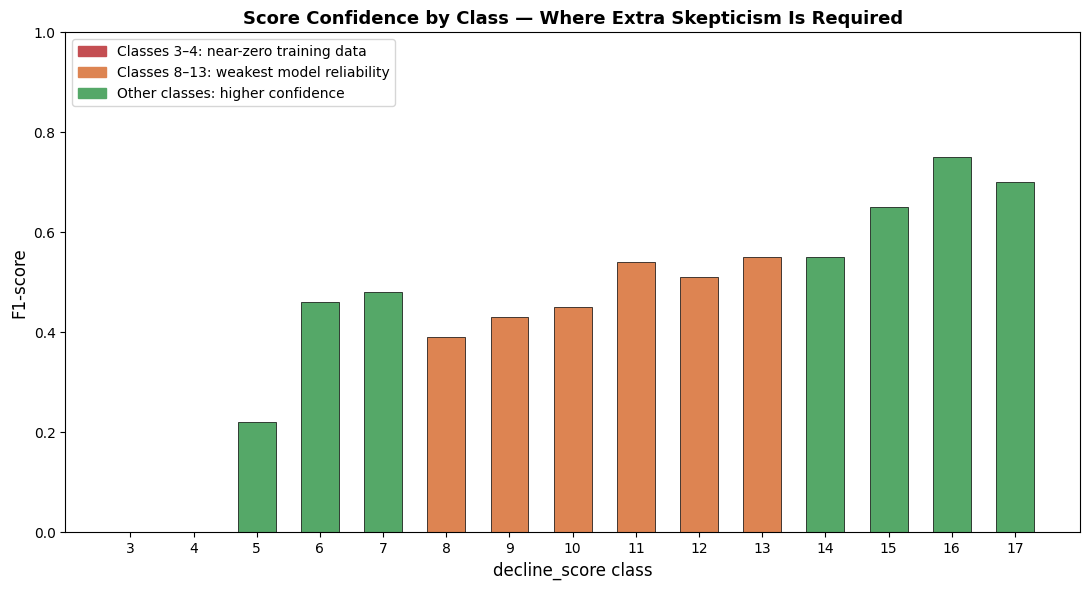

In [34]:
# Figure 4

classes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
f1_scores = [0.00, 0.00, 0.22, 0.46, 0.48, 0.39, 0.43, 0.45, 0.54, 0.51, 0.55, 0.55, 0.65, 0.75, 0.70]

confidence_tier = []
colors = []
for c, f1 in zip(classes, f1_scores):
    if c in [3, 4]:
        confidence_tier.append('Near-zero data')
        colors.append('#C44E52')
    elif 8 <= c <= 13:
        confidence_tier.append('Weakest reliability')
        colors.append('#DD8452')
    else:
        confidence_tier.append('Higher confidence')
        colors.append('#55A868')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(classes, f1_scores, color=colors, width=0.6, edgecolor='black', linewidth=0.5)

ax.set_xlabel('decline_score class', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_xticks(classes)
ax.set_title('Score Confidence by Class — Where Extra Skepticism Is Required', fontsize=13, fontweight='bold')

legend_elements = [
    plt.Rectangle((0,0),1,1, color='#C44E52', label='Classes 3–4: near-zero training data'),
    plt.Rectangle((0,0),1,1, color='#DD8452', label='Classes 8–13: weakest model reliability'),
    plt.Rectangle((0,0),1,1, color='#55A868', label='Other classes: higher confidence'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('work/outputs/confidence_tiers_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

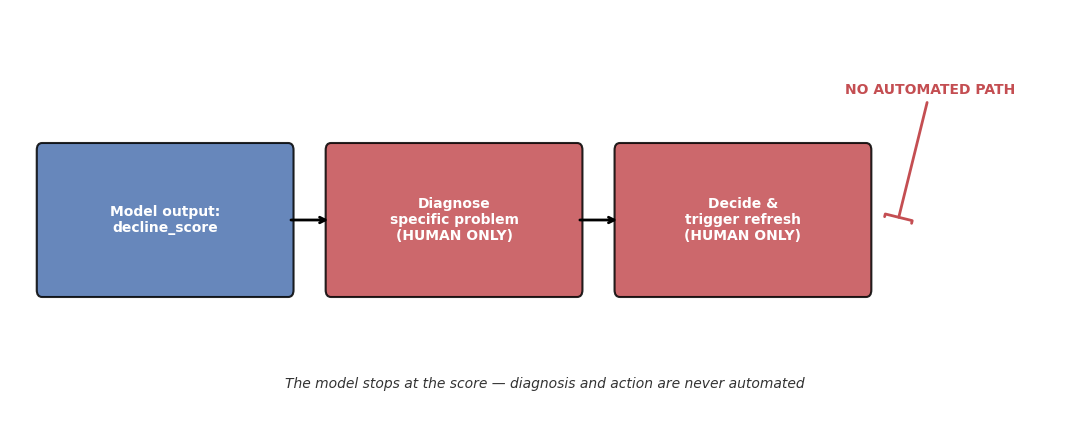

In [35]:
# Figure 5
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    (0.3, 1, 2.3, 1, '#4C72B0', "Model output:\ndecline_score"),
    (3.0, 1, 2.3, 1, '#C44E52', "Diagnose\nspecific problem\n(HUMAN ONLY)"),
    (5.7, 1, 2.3, 1, '#C44E52', "Decide &\ntrigger refresh\n(HUMAN ONLY)"),
]

for x, y, w, h, color, label in steps:
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          linewidth=1.5, edgecolor='black', facecolor=color, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.annotate('', xy=(3.0, 1.5), xytext=(2.6, 1.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.annotate('', xy=(5.7, 1.5), xytext=(5.3, 1.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.annotate('NO AUTOMATED PATH', xy=(8.3, 1.5), xytext=(8.6, 2.4),
            fontsize=10, color='#C44E52', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='-[', lw=2, color='#C44E52'))

ax.text(5, 0.3, 'The model stops at the score — diagnosis and action are never automated',
        ha='center', fontsize=10, style='italic', color='#333333')

plt.tight_layout()
plt.savefig('work/outputs/never_automated_steps.png', dpi=300, bbox_inches='tight')
plt.show()

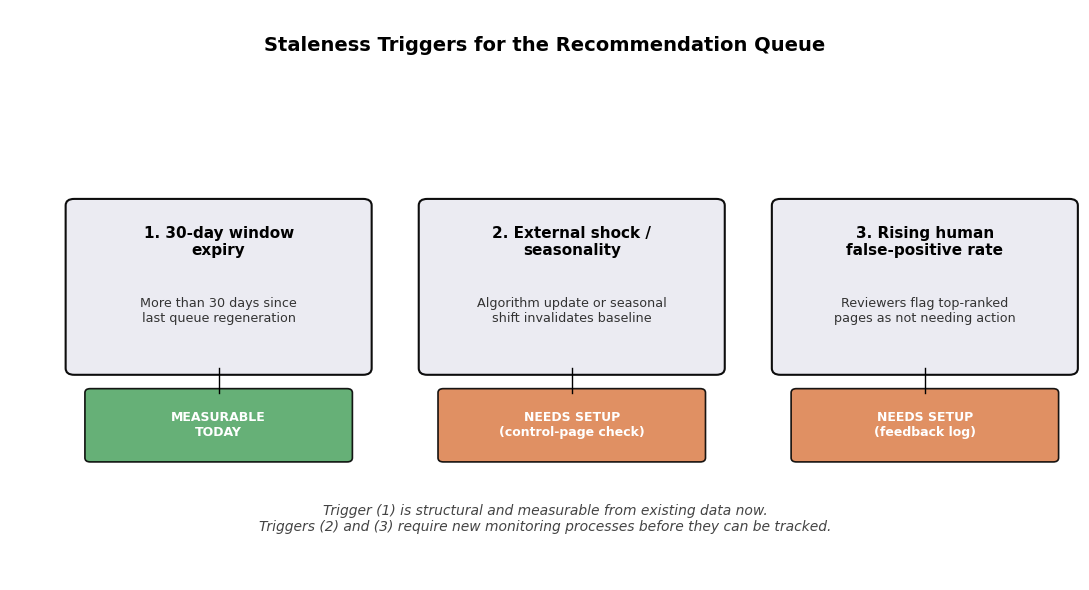

In [36]:
# Figure 6
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

ax.text(5, 6.5, 'Staleness Triggers for the Recommendation Queue',
        ha='center', fontsize=14, fontweight='bold')

triggers = [
    (1, '30-day window\nexpiry',
     'More than 30 days since\nlast queue regeneration',
     'MEASURABLE\nTODAY', '#55A868'),
    (2, 'External shock /\nseasonality',
     'Algorithm update or seasonal\nshift invalidates baseline',
     'NEEDS SETUP\n(control-page check)', '#DD8452'),
    (3, 'Rising human\nfalse-positive rate',
     'Reviewers flag top-ranked\npages as not needing action',
     'NEEDS SETUP\n(feedback log)', '#DD8452'),
]

x_positions = [0.6, 3.9, 7.2]
width = 2.7

for (num, title, desc, status, color), x in zip(triggers, x_positions):
    # main box
    box = FancyBboxPatch((x, 2.6), width, 2.0, boxstyle="round,pad=0.08",
                          linewidth=1.5, edgecolor='black', facecolor='#EAEAF2', alpha=0.95)
    ax.add_patch(box)
    ax.text(x + width/2, 4.15, f'{num}. {title}', ha='center', va='center',
            fontsize=11, fontweight='bold')
    ax.text(x + width/2, 3.3, desc, ha='center', va='center', fontsize=9.2, color='#333333')

    # status badge
    badge = FancyBboxPatch((x + 0.15, 1.5), width - 0.3, 0.8, boxstyle="round,pad=0.05",
                            linewidth=1.2, edgecolor='black', facecolor=color, alpha=0.9)
    ax.add_patch(badge)
    ax.text(x + width/2, 1.9, status, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

    # connector line
    ax.plot([x + width/2, x + width/2], [2.6, 2.3], color='black', linewidth=1)

ax.text(5, 0.6, 'Trigger (1) is structural and measurable from existing data now.\n'
                'Triggers (2) and (3) require new monitoring processes before they can be tracked.',
        ha='center', fontsize=10, style='italic', color='#444444')

plt.tight_layout()
plt.savefig('work/outputs/staleness_triggers.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 7: Distribution of Pages by Recommendation Tiers

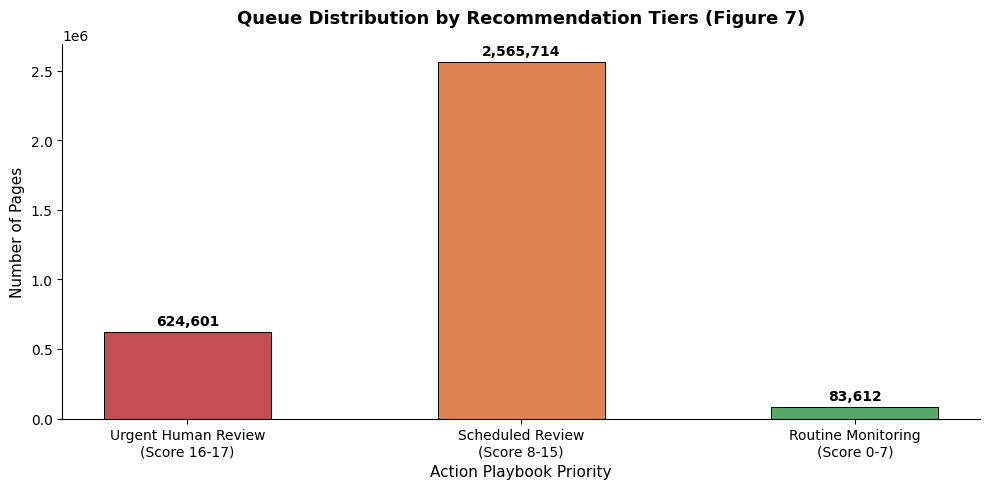

In [37]:
# Classify each row in data into the 3 tiers defined in recommendations
def get_tier(score):
    if 16 <= score <= 17:
        return 'Urgent Human Review\n(Score 16-17)'
    elif 8 <= score <= 15:
        return 'Scheduled Review\n(Score 8-15)'
    else:
        return 'Routine Monitoring\n(Score 0-7)'

ranked_queue['recommendation_tier'] = ranked_queue['decline_score'].apply(get_tier)
tier_counts = ranked_queue['recommendation_tier'].value_counts().reindex([
    'Urgent Human Review\n(Score 16-17)',
    'Scheduled Review\n(Score 8-15)',
    'Routine Monitoring\n(Score 0-7)'
]).fillna(0)

# Create a clean and modern visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C44E52', '#DD8452', '#55A868']

bars = ax.bar(tier_counts.index, tier_counts.values, color=colors, width=0.5, edgecolor='black', linewidth=0.7)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, height + (max(tier_counts.values)*0.01),
            f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Queue Distribution by Recommendation Tiers (Figure 7)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Pages', fontsize=11)
ax.set_xlabel('Action Playbook Priority', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('work/outputs/recommendation_tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 5-minute demo

**5-Minute Demo Outline**

0:00–0:30 — ***The Problem***

SEO teams can't manually review every page to catch content decline before it costs traffic/revenue.

0:30–1:30 — ***The Approach***

Built decline_score (0–17): a rule-based label from 17 signals (search visibility, CTR, engagement, traffic channels) comparing a prev30 vs. last30 window.
Trained a classifier on prev30-only features (no last30/future leakage) to predict this score, so it generalizes to new content.

1:30–2:30 — ***Show the Output***

Open the ranked queue: show a top-tier page (score 15–17), its triggered reason codes, and why it's flagged urgent.
Show a mid-tier page (score 8–13) to contrast: more ambiguous, flagged for manual verification, not automatic action.

2:30–4:00 — ***Honest Results***

Random split scored an inflated F1 of 0.58 — traced to 97.38% of test-set content already appearing in training.
Client-holdout split (27 clients, 21 train / 6 test, zero overlap): honest F1 = 0.44. This is the number that governs trust in the output.

4:00–5:00 — ***Limits and What's Next***

Cannot predict Google's algorithm, guarantee rankings, or prove refresh causes recovery — decision-support only.
Weakest on near-zero-data classes; strongest at score extremes.
Next: 30-day regeneration cadence, reviewer feedback loop to catch staleness.

# Social-post cut


Built an ML pipeline that flags which pages in a content portfolio are declining in search performance, before the traffic loss becomes obvious. Using 17 signals (search visibility, CTR, engagement, cross-channel traffic, etc) across a rolling 60-day window, I trained a random forest classifier and ranked content by decline risk. Later showcased the pages which need urgent look, which need to a scheduled review, and which can be in monitor phase.

The most valuable part wasn't the model — it was catching a leakage bug: a naive split inflated my F1 score to 0.58, but a proper client-holdout split (zero client overlap between train/test) revealed the honest number: 0.44. Reporting that gap, not hiding it, is the actual finding worth sharing.

Output: a human-reviewed action playbook — ranked pages, reason codes, confidence tiers, and clear no-go cases — not an autonomous decision system.

# Three-Sentence Employer-Facing Summary


I built a multi-class classification pipeline that prioritizes SEO content review by decline score, engineering features from a 90-day rolling window and validating with a client-holdout split (27 clients, zero train/test overlap) to prevent data leakage. I identified and quantified a leakage issue in a naive random split — inflating F1 from an honest 0.44 to a misleading 0.58 via 97% content overlap — and reported the corrected, methodologically sound result rather than the inflated one. The final deliverable is a ranked action playbook with reason codes, confidence tiers, and explicit human-review requirements, designed as a decision-support tool rather than an automated system.

## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [✓] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [✓] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
